# 03 - Validar RiverSP da passagem teste

Baixa e inspeciona apenas o candidato `RIVERSP` selecionado no notebook 02 para avaliar suporte observacional preliminar próximo aos 13 exutórios. Este notebook não baixa PIXC.

## Objetivo

Validar, com um único produto RiverSP vetorial, se há feições SWOT próximas aos exutórios. A etapa usa o candidato `RIVERSP` de rank 1 em `outputs/tabelas/candidatos_passagem_teste_swot.csv`, baixa somente esse ZIP se necessário e gera uma primeira tabela de distância ponto-feição.

## Por que RiverSP primeiro?

RiverSP é mais leve que PIXC e já entrega feições vetoriais de rios/reaches/nodes. Ele é uma boa primeira verificação porque permite testar proximidade espacial e atributos hidrológicos sem baixar um NetCDF PIXC grande.

In [1]:
from __future__ import annotations

import json
import logging
import tempfile
import zipfile
from pathlib import Path
from urllib.parse import urlparse

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point


In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'requirements.txt').exists() and (candidate / 'src' / 'check_environment.py').exists():
            return candidate
    fallback = Path.home() / 'mystorage' / 'PPGGAG1889' / 'atividade3_swot'
    if fallback.exists():
        return fallback
    raise RuntimeError('FALHA: rode este notebook dentro do repositorio atividade3_swot.')

PROJECT_ROOT = find_project_root(Path.cwd())
EXUTORIOS_CSV = PROJECT_ROOT / 'dados' / 'exutorios.csv'
CANDIDATOS_CSV = PROJECT_ROOT / 'outputs' / 'tabelas' / 'candidatos_passagem_teste_swot.csv'
RAW_DIR = PROJECT_ROOT / 'dados' / 'raw' / 'swot' / 'riversp'
INTERMEDIATE_DIR = PROJECT_ROOT / 'dados' / 'intermediarios' / 'swot' / 'riversp'
OUTPUT_TABLE = PROJECT_ROOT / 'outputs' / 'tabelas' / 'validacao_riversp_exutorios.csv'
OUTPUT_FIGURE = PROJECT_ROOT / 'outputs' / 'figuras' / '03_validar_riversp_passagem_teste.png'
LOG_FILE = PROJECT_ROOT / 'outputs' / 'logs' / '03_validar_riversp_passagem_teste.log'

for path in [RAW_DIR, INTERMEDIATE_DIR, OUTPUT_TABLE.parent, OUTPUT_FIGURE.parent, LOG_FILE.parent]:
    path.mkdir(parents=True, exist_ok=True)

logging.basicConfig(filename=LOG_FILE, filemode='w', level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
print('OK raiz do projeto:', PROJECT_ROOT)
print('OK raw:', RAW_DIR)
print('OK log:', LOG_FILE)


OK raiz do projeto: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot
OK raw: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot/dados/raw/swot/riversp
OK log: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot/outputs/logs/03_validar_riversp_passagem_teste.log


## Entradas e candidato selecionado

A célula abaixo valida os 13 exutórios e seleciona automaticamente o candidato `RIVERSP` com `rank = 1`. Se a tabela não tiver esse candidato, o notebook falha explicitamente.

In [3]:
expected_columns = ['id', 'latitude', 'longitude']
if not EXUTORIOS_CSV.exists():
    raise FileNotFoundError(f'FALHA: arquivo de exutorios nao encontrado: {EXUTORIOS_CSV}')
if not CANDIDATOS_CSV.exists():
    raise FileNotFoundError(f'FALHA: tabela de candidatos nao encontrada: {CANDIDATOS_CSV}')

exutorios = pd.read_csv(EXUTORIOS_CSV)
if list(exutorios.columns) != expected_columns:
    raise ValueError(f'FALHA: colunas esperadas {expected_columns}, colunas encontradas {list(exutorios.columns)}')
if len(exutorios) != 13:
    raise ValueError(f'FALHA: esperados 13 exutorios, encontrados {len(exutorios)}')
exutorios['latitude'] = pd.to_numeric(exutorios['latitude'], errors='raise')
exutorios['longitude'] = pd.to_numeric(exutorios['longitude'], errors='raise')

candidatos = pd.read_csv(CANDIDATOS_CSV)
riversp = candidatos[(candidatos['produto'].str.upper() == 'RIVERSP') & (candidatos['rank'] == 1)]
if riversp.empty:
    raise ValueError('FALHA: candidato RIVERSP rank 1 nao encontrado em candidatos_passagem_teste_swot.csv')

candidate = riversp.iloc[0].to_dict()
url = str(candidate['download_url'])
granule_id = str(candidate['granule_id'])
expected_mb = float(candidate['tamanho_mb']) if pd.notna(candidate.get('tamanho_mb')) else None
filename = Path(urlparse(url).path).name or f'{granule_id}.zip'
if not filename.lower().endswith('.zip'):
    raise ValueError(f'FALHA: URL do candidato RIVERSP nao aponta para .zip: {url}')
zip_path = RAW_DIR / filename

logging.info('Candidato RIVERSP selecionado: %s', json.dumps(candidate, ensure_ascii=False))
print('OK candidato RIVERSP rank 1')
print('granule_id:', granule_id)
print('url:', url)
print('tamanho esperado MB:', expected_mb)
print('destino:', zip_path)
display(exutorios)


OK candidato RIVERSP rank 1
granule_id: SWOT_L2_HR_RiverSP_Reach_055_255_SA_20260830T001107_20260830T002121_PID0_01
url: https://archive.swot.podaac.earthdata.nasa.gov/podaac-swot-ops-cumulus-protected/SWOT_L2_HR_RiverSP_D/SWOT_L2_HR_RiverSP_Reach_055_255_SA_20260830T001107_20260830T002121_PID0_01.zip
tamanho esperado MB: 10.732728004455566
destino: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot/dados/raw/swot/riversp/SWOT_L2_HR_RiverSP_Reach_055_255_SA_20260830T001107_20260830T002121_PID0_01.zip


,id,latitude,longitude
0,P01,-15.539765,-47.972069
1,P02,-15.541334,-47.969589
2,P03,-15.541921,-47.981644
3,P04,-15.542892,-47.980763
4,P05,-15.542658,-47.979778
5,P06,-15.543083,-47.979286
6,P07,-15.541673,-47.979366
7,P08,-15.537334,-47.975750
8,P09,-15.537017,-47.975281
9,P10,-15.536032,-47.976860


## Download controlado

A próxima célula baixa somente o ZIP RiverSP selecionado, se ele ainda não existir em `dados/raw/swot/riversp/`. Ela usa `earthaccess` para autenticação/sessão quando necessário. Nenhum PIXC é baixado.

In [4]:
try:
    import earthaccess
except Exception as exc:
    logging.exception('Falha ao importar earthaccess')
    raise RuntimeError('FALHA: earthaccess nao esta instalado. Rode pip install -r requirements.txt.') from exc

already_exists = zip_path.exists() and zip_path.stat().st_size > 0
if already_exists:
    downloaded_paths = [zip_path]
    status_download = 'arquivo_ja_existia'
else:
    try:
        # Necessario para URLs protegidas do PO.DAAC. Se a autenticacao falhar,
        # o erro fica preservado no output do notebook.
        earthaccess.login(strategy='interactive', persist=True)
        downloaded_paths = earthaccess.download(url, local_path=RAW_DIR, threads=1, show_progress=True)
        status_download = 'baixado'
    except Exception as exc:
        logging.exception('Falha no download RiverSP: %s', url)
        raise RuntimeError('FALHA: download do RIVERSP nao concluido. Verifique login Earthdata, URL e conectividade.') from exc

if not downloaded_paths:
    raise RuntimeError('FALHA: earthaccess.download nao retornou caminho baixado.')
zip_path = Path(downloaded_paths[0])
if not zip_path.exists():
    candidate_path = RAW_DIR / filename
    if candidate_path.exists():
        zip_path = candidate_path
    else:
        raise FileNotFoundError(f'FALHA: arquivo baixado nao encontrado: {downloaded_paths[0]}')

downloaded_mb = zip_path.stat().st_size / (1024 * 1024)
logging.info('URL usada: %s', url)
logging.info('Arquivo: %s', filename)
logging.info('Tamanho esperado MB: %s', expected_mb)
logging.info('Tamanho local MB: %.3f', downloaded_mb)
logging.info('Caminho local: %s', zip_path)
logging.info('Status download: %s', status_download)

print('OK download RiverSP:', status_download)
print('arquivo:', zip_path)
print('tamanho local MB:', round(downloaded_mb, 3))


Enter your Earthdata Login username:  skwrtiny
Enter your Earthdata password:  ········


  0%|          | 0/1 [00:00<?, ?it/s]

OK download RiverSP: baixado
arquivo: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot/dados/raw/swot/riversp/SWOT_L2_HR_RiverSP_Reach_055_255_SA_20260830T001107_20260830T002121_PID0_01.zip
tamanho local MB: 10.733


## Inspeção controlada do ZIP

Antes de assumir qualquer esquema interno, o ZIP é listado. O notebook procura arquivos vetoriais/tabelares e prioriza camadas de reach quando existirem.

In [5]:
if not zipfile.is_zipfile(zip_path):
    raise zipfile.BadZipFile(f'FALHA: arquivo nao e um ZIP valido: {zip_path}')

with zipfile.ZipFile(zip_path) as zf:
    members = zf.infolist()
    zip_inventory = pd.DataFrame([
        {'nome': m.filename, 'tamanho_bytes': m.file_size, 'compactado_bytes': m.compress_size}
        for m in members
    ]).sort_values('nome').reset_index(drop=True)

logging.info('Arquivos internos do ZIP: %s', len(zip_inventory))
for name in zip_inventory['nome'].tolist():
    logging.info('ZIP member: %s', name)

vector_ext = ('.shp', '.gpkg', '.geojson', '.json')
table_ext = ('.csv', '.parquet')
vector_members = [n for n in zip_inventory['nome'] if n.lower().endswith(vector_ext)]
table_members = [n for n in zip_inventory['nome'] if n.lower().endswith(table_ext)]

print('OK arquivos no ZIP:', len(zip_inventory))
print('vetoriais candidatos:', vector_members)
print('tabelares candidatos:', table_members)
display(zip_inventory)


OK arquivos no ZIP: 5
vetoriais candidatos: ['SWOT_L2_HR_RiverSP_Reach_055_255_SA_20260830T001107_20260830T002121_PID0_01.shp']
tabelares candidatos: []


,nome,tamanho_bytes,compactado_bytes
0,SWOT_L2_HR_RiverSP_Reach_055_255_SA_20260830T0...,2808088,2808088
1,SWOT_L2_HR_RiverSP_Reach_055_255_SA_20260830T0...,144,144
2,SWOT_L2_HR_RiverSP_Reach_055_255_SA_20260830T0...,8323836,8323836
3,SWOT_L2_HR_RiverSP_Reach_055_255_SA_20260830T0...,108209,108209
4,SWOT_L2_HR_RiverSP_Reach_055_255_SA_20260830T0...,12604,12604


In [6]:
def member_priority(name: str) -> tuple[int, str]:
    lower = name.lower()
    if lower.endswith('.shp') and 'reach' in lower:
        return (0, lower)
    if lower.endswith('.shp'):
        return (1, lower)
    if lower.endswith(('.gpkg', '.geojson')):
        return (2, lower)
    if lower.endswith('.json'):
        return (3, lower)
    return (9, lower)

if not vector_members:
    raise RuntimeError('FALHA: nenhum arquivo vetorial reconhecido dentro do ZIP RiverSP.')

selected_member = sorted(vector_members, key=member_priority)[0]
logging.info('Arquivo vetorial selecionado para leitura: %s', selected_member)
print('OK camada/arquivo selecionado:', selected_member)

read_errors = []
riversp_gdf = None
try:
    riversp_gdf = gpd.read_file(f'zip://{zip_path}!{selected_member}')
except Exception as exc:
    read_errors.append(f'zip:// falhou: {exc}')

if riversp_gdf is None:
    extract_dir = INTERMEDIATE_DIR / zip_path.stem
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        related_prefix = Path(selected_member).with_suffix('').name
        for member in zf.namelist():
            base = Path(member).with_suffix('').name
            if base == related_prefix:
                zf.extract(member, extract_dir)
    extracted_candidates = list(extract_dir.rglob(Path(selected_member).name))
    if not extracted_candidates:
        raise RuntimeError('FALHA: nao foi possivel extrair o arquivo vetorial selecionado.')
    try:
        riversp_gdf = gpd.read_file(extracted_candidates[0])
    except Exception as exc:
        read_errors.append(f'extracao falhou: {exc}')
        logging.error('Erros de leitura: %s', read_errors)
        raise RuntimeError('FALHA: nao foi possivel ler a camada RiverSP com geopandas.') from exc

if riversp_gdf.empty:
    raise RuntimeError('FALHA: camada RiverSP lida, mas sem feicoes.')
if riversp_gdf.crs is None:
    riversp_gdf = riversp_gdf.set_crs('EPSG:4326', allow_override=True)

logging.info('CRS RiverSP: %s', riversp_gdf.crs)
logging.info('Total feicoes RiverSP: %s', len(riversp_gdf))
logging.info('Colunas RiverSP: %s', list(riversp_gdf.columns))
print('OK RiverSP carregado')
print('CRS:', riversp_gdf.crs)
print('feicoes:', len(riversp_gdf))
print('colunas:', list(riversp_gdf.columns))
display(riversp_gdf.head())


OK camada/arquivo selecionado: SWOT_L2_HR_RiverSP_Reach_055_255_SA_20260830T001107_20260830T002121_PID0_01.shp
OK RiverSP carregado
CRS: EPSG:4326
feicoes: 1563
colunas: ['reach_id', 'time', 'time_tai', 'time_str', 'p_lat', 'p_lon', 'river_name', 'wse', 'wse_u', 'wse_r_u', 'wse_c', 'wse_c_u', 'slope', 'slope_u', 'slope_r_u', 'slope2', 'slope2_u', 'slope2_r_u', 'width', 'width_u', 'width_c', 'width_c_u', 'area_total', 'area_tot_u', 'area_detct', 'area_det_u', 'area_wse', 'd_x_area', 'd_x_area_u', 'layovr_val', 'node_dist', 'loc_offset', 'xtrk_dist', 'dschg_c', 'dschg_c_u', 'dschg_csf', 'dschg_c_q', 'dschg_gc', 'dschg_gc_u', 'dschg_gcsf', 'dschg_gc_q', 'dschg_m', 'dschg_m_u', 'dschg_msf', 'dschg_m_q', 'dschg_gm', 'dschg_gm_u', 'dschg_gmsf', 'dschg_gm_q', 'dschg_b', 'dschg_b_u', 'dschg_bsf', 'dschg_b_q', 'dschg_gb', 'dschg_gb_u', 'dschg_gbsf', 'dschg_gb_q', 'dschg_h', 'dschg_h_u', 'dschg_hsf', 'dschg_h_q', 'dschg_gh', 'dschg_gh_u', 'dschg_ghsf', 'dschg_gh_q', 'dschg_o', 'dschg_o_u', 'dsch

,reach_id,time,time_tai,time_str,p_lat,p_lon,river_name,wse,wse_u,wse_r_u,...,p_wid_var,p_n_nodes,p_dist_out,p_length,p_maf,p_dam_id,p_n_ch_max,p_n_ch_mod,p_low_slp,geometry
0,62307000495,8.413645e+08,8.413645e+08,2026-08-30T00:21:08Z,-0.752370,-48.320137,no_data,2.0527,0.09163,0.01722,...,65065.226,98,67098.586,19497.606869,-1.000000e+12,0,1,1,0,"LINESTRING (-48.27406 -0.67733, -48.27418 -0.6..."
1,62307000505,8.413645e+08,8.413645e+08,2026-08-30T00:21:05Z,-0.888904,-48.417239,no_data,1.8300,0.09289,0.02300,...,42253.788,88,84690.168,17591.582233,-1.000000e+12,0,1,1,0,"LINESTRING (-48.36996 -0.82483, -48.37012 -0.8..."
2,62307000515,8.413645e+08,8.413645e+08,2026-08-30T00:20:59Z,-1.196590,-48.597724,no_data,0.9308,0.09415,0.02764,...,48006.641,61,121702.621,12142.851949,-1.000000e+12,0,1,1,0,"LINESTRING (-48.57497 -1.14641, -48.57508 -1.1..."
3,62307000525,8.413645e+08,8.413645e+08,2026-08-30T00:20:58Z,-1.282625,-48.642121,no_data,0.6945,0.09449,0.02879,...,29405.400,46,130954.307,9251.685421,-1.000000e+12,0,2,1,0,"LINESTRING (-48.62191 -1.24576, -48.62204 -1.2..."
4,62307000535,8.413645e+08,8.413645e+08,2026-08-30T00:20:57Z,-1.340182,-48.671805,no_data,0.4780,0.10711,0.05808,...,4139.468,25,135995.839,5041.532612,-1.000000e+12,0,1,1,0,"LINESTRING (-48.66221 -1.31925, -48.66234 -1.3..."


## Suporte observacional preliminar

Aqui, suporte observacional preliminar significa que existe uma feição RiverSP próxima ao exutório dentro de uma distância limite. Isso ainda não garante qualidade hidrológica final, mas indica que o produto vetorial tem uma feição SWOT espacialmente compatível com o ponto.

In [7]:
SUPPORT_DISTANCE_M = 5000

points_gdf = gpd.GeoDataFrame(
    exutorios.copy(),
    geometry=gpd.points_from_xy(exutorios['longitude'], exutorios['latitude']),
    crs='EPSG:4326',
)
metric_crs = points_gdf.estimate_utm_crs()
if metric_crs is None:
    raise RuntimeError('FALHA: nao foi possivel estimar CRS metrico para distancias.')

points_m = points_gdf.to_crs(metric_crs)
riversp_m = riversp_gdf.to_crs(metric_crs)

id_candidates = ['reach_id', 'node_id', 'river_name', 'name', 'id', 'feature_id', 'lake_id']
id_columns = [c for c in id_candidates if c in riversp_m.columns]
attribute_columns = [c for c in ['reach_id', 'node_id', 'river_name', 'wse', 'width', 'slope', 'quality_f', 'dark_frac', 'geometry'] if c in riversp_m.columns]
if not attribute_columns:
    attribute_columns = list(riversp_m.columns[: min(8, len(riversp_m.columns))])

rows = []
for _, point in points_m.iterrows():
    distances = riversp_m.geometry.distance(point.geometry)
    nearest_idx = distances.idxmin()
    nearest = riversp_m.loc[nearest_idx]
    dist_m = float(distances.loc[nearest_idx])
    feature_id = ''
    for col in id_columns:
        value = nearest.get(col)
        if pd.notna(value):
            feature_id = str(value)
            break
    support = 'sim' if dist_m <= SUPPORT_DISTANCE_M else 'nao'
    attrs = {col: nearest.get(col) for col in attribute_columns if col != 'geometry'}
    obs = f"Distancia ao RiverSP mais proximo: {dist_m:.1f} m; limite preliminar: {SUPPORT_DISTANCE_M} m; attrs: {attrs}"
    rows.append({
        'id': point['id'],
        'latitude': point['latitude'],
        'longitude': point['longitude'],
        'distancia_m_feicao_riversp': round(dist_m, 2),
        'feicao_mais_proxima_id': feature_id,
        'suporte_riversp': support,
        'observacoes': obs,
    })

validation = pd.DataFrame(rows)
validation.to_csv(OUTPUT_TABLE, index=False, encoding='utf-8')
logging.info('Tabela de validacao salva: %s', OUTPUT_TABLE)
logging.info('Suporte RiverSP: %s', validation['suporte_riversp'].value_counts().to_dict())
print('OK tabela salva:', OUTPUT_TABLE)
display(validation)


OK tabela salva: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot/outputs/tabelas/validacao_riversp_exutorios.csv


,id,latitude,longitude,distancia_m_feicao_riversp,feicao_mais_proxima_id,suporte_riversp,observacoes
0,P01,-15.539765,-47.972069,162704.85,62449000141,nao,Distancia ao RiverSP mais proximo: 162704.9 m;...
1,P02,-15.541334,-47.969589,162973.55,62449000141,nao,Distancia ao RiverSP mais proximo: 162973.6 m;...
2,P03,-15.541921,-47.981644,161680.36,62449000141,nao,Distancia ao RiverSP mais proximo: 161680.4 m;...
3,P04,-15.542892,-47.980763,161776.61,62449000141,nao,Distancia ao RiverSP mais proximo: 161776.6 m;...
4,P05,-15.542658,-47.979778,161881.94,62449000141,nao,Distancia ao RiverSP mais proximo: 161881.9 m;...
5,P06,-15.543083,-47.979286,161935.51,62449000141,nao,Distancia ao RiverSP mais proximo: 161935.5 m;...
6,P07,-15.541673,-47.979366,161924.50,62449000141,nao,Distancia ao RiverSP mais proximo: 161924.5 m;...
7,P08,-15.537334,-47.975750,162306.21,62449000141,nao,Distancia ao RiverSP mais proximo: 162306.2 m;...
8,P09,-15.537017,-47.975281,162356.14,62449000141,nao,Distancia ao RiverSP mais proximo: 162356.1 m;...
9,P10,-15.536032,-47.976860,162185.37,62449000141,nao,Distancia ao RiverSP mais proximo: 162185.4 m;...


OK figura salva: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot/outputs/figuras/03_validar_riversp_passagem_teste.png


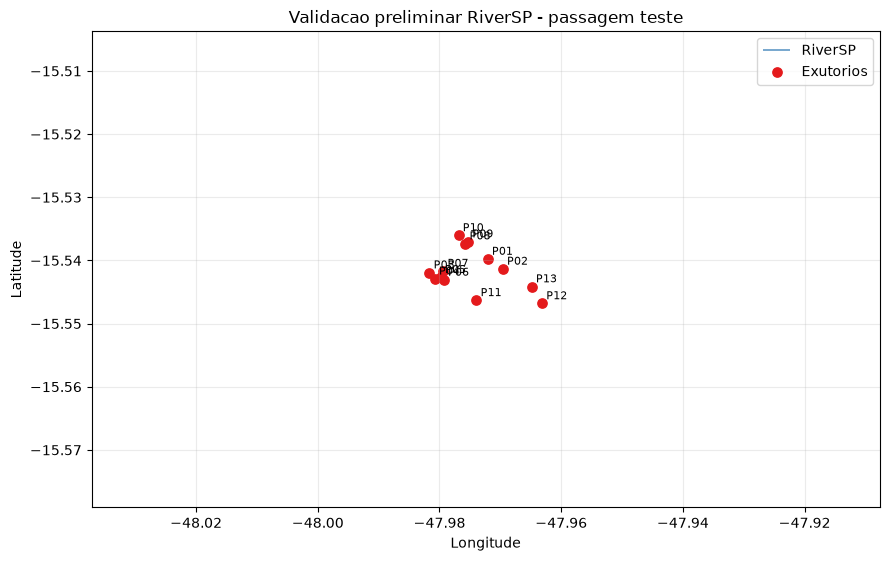

In [8]:
fig, ax = plt.subplots(figsize=(9, 8))
try:
    riversp_plot = riversp_gdf.to_crs('EPSG:4326')
    points_plot = points_gdf.to_crs('EPSG:4326')
    minx, miny, maxx, maxy = points_plot.total_bounds
    pad_x = max((maxx - minx) * 3, 0.03)
    pad_y = max((maxy - miny) * 3, 0.03)
    riversp_plot.plot(ax=ax, color='#377eb8', linewidth=1.2, alpha=0.8, label='RiverSP')
    points_plot.plot(ax=ax, color='#e41a1c', markersize=45, label='Exutorios')
    for _, row in points_plot.iterrows():
        ax.annotate(row['id'], (row.geometry.x, row.geometry.y), xytext=(3, 3), textcoords='offset points', fontsize=8)
    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)
    ax.set_title('Validacao preliminar RiverSP - passagem teste')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUTPUT_FIGURE, dpi=180)
    logging.info('Figura salva: %s', OUTPUT_FIGURE)
    print('OK figura salva:', OUTPUT_FIGURE)
    plt.show()
except Exception as exc:
    logging.exception('Falha ao gerar figura')
    raise RuntimeError('FALHA: nao foi possivel gerar a figura de validacao RiverSP.') from exc


## Limitações desta etapa

- O suporte é preliminar e baseado em distância até feições RiverSP.
- A distância limite de 5 km é operacional e deve ser revisada conforme o objetivo hidrológico.
- A etapa ainda não verifica PIXC, máscara de água, qualidade detalhada ou consistência temporal.
- O produto RiverSP pode conter reaches/nodes fora do canal exato do exutório; a validação fina exigirá inspeção posterior.


## Próximos passos

1. Revisar `outputs/tabelas/validacao_riversp_exutorios.csv`.
2. Verificar quais exutórios ficaram com `suporte_riversp = sim`.
3. Conferir visualmente `outputs/figuras/03_validar_riversp_passagem_teste.png`.
4. Se RiverSP der suporte suficiente, avançar para análise temporal leve; se não, considerar LakeSP ou, com cautela, um PIXC controlado.